# data cleaning on dataset

In [8]:
import pandas as pd
df = pd.read_csv('/Users/ryanlin/Downloads/job_des_full.csv')
# Display the first few rows of the dataframe
df.head()

,resume_text,job_description_text,label,job_description_clean,skills_extracted,matched_category,overlap_score
0,SummaryHighly motivated Sales Associate with e...,Net2Source Inc. is an award-winning total work...,No Fit,net2source inc is an award winning total workf...,"['user training and support', 'leadership deve...",INFORMATION-TECHNOLOGY,41
1,Professional SummaryCurrently working with Cat...,At Salas OBrien we tell our clients that were ...,No Fit,at salas obrien we tell our clients that were ...,"['windows operating system', 'information tech...",INFORMATION-TECHNOLOGY,44
2,SummaryI started my construction career in Jun...,Schweitzer Engineering Laboratories (SEL) Infr...,No Fit,schweitzer engineering laboratories sel infras...,"['information technology', 'information securi...",INFORMATION-TECHNOLOGY,35
3,SummaryCertified Electrical Foremanwith thirte...,"Mizick Miller & Company, Inc. is looking for a...",No Fit,mizick miller company inc is looking for a dyn...,"['microsoft office suite', 'communication skil...",BUSINESS-DEVELOPMENT,22
4,SummaryWith extensive experience in business/r...,Life at Capgemini\nCapgemini supports all aspe...,No Fit,life at capgemini capgemini supports all aspec...,"['software engineering', 'industry knowledge',...",INFORMATION-TECHNOLOGY,46


# Check for missing values

In [9]:

df.isnull().sum()

resume_text              0
job_description_text     0
label                    0
job_description_clean    0
skills_extracted         0
matched_category         0
overlap_score            0
dtype: int64

# Check for duplicates


In [10]:
print(df.duplicated().sum())
df[df.duplicated()]

1


,resume_text,job_description_text,label,job_description_clean,skills_extracted,matched_category,overlap_score
2326,SummaryHighly proficient Business Analyst with...,"The Senior Manager, Data Architecture & Data E...",No Fit,the senior manager data architecture data engi...,"['master data management', 'communication skil...",FINANCE,66


In [11]:
# Remove one of the duplicate rows
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

# Some Exploratory Data Analysis (EDA) on overlap_score

# A quick snapshot of the numeric, textual summary (describe) and the visual distribution (hist) of the overlap_score data

count    6240.000000
mean       36.257051
std        17.362533
min         5.000000
25%        22.000000
50%        36.000000
75%        47.000000
max        84.000000
Name: overlap_score, dtype: float64


<Axes: >

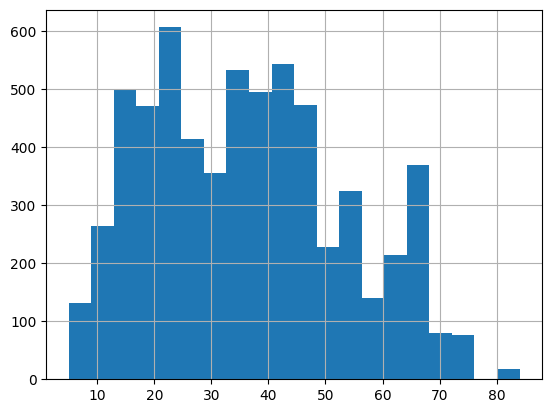

In [15]:
print(df['overlap_score'].describe())
df['overlap_score'].hist(bins=20)

In [12]:
#for each label the mean std of the overlap_score
df.groupby('label')['overlap_score'].agg(['mean', 'std'])

,mean,std
label,,
Good Fit,38.740597,16.952433
No Fit,36.031827,17.485308
Potential Fit,34.250643,17.230838


This is bad because we want to have a higher overlap score for the "Good Fit" category and lower scores for the "No Fit" and "Potential Fit" categories. the possibility of misclassifying candidates is high.

Also, the standard deviation for all labels is quite high, indicating that there is a lot of variability in the overlap scores within each category. This further complicates the classification task.